In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('play-yes-no.csv')

In [ ]:
df.head()

,Unnamed: 0,Weather,Temp,Humidity,Windy,Play
0,0,Cloudy,Hot,Yes,No,Play_Yes
1,1,Sunny,Cold,Yes,Yes,Play_Yes
2,2,Sunny,Hot,Yes,Yes,Play_No
3,3,Cloudy,Hot,Yes,No,Play_Yes
4,4,Cloudy,Mild,Yes,Yes,Play_Yes


In [ ]:
df.drop(columns='Unnamed: 0',inplace=True)

In [ ]:
df

,Weather,Temp,Humidity,Windy,Play
0,Cloudy,Hot,Yes,No,Play_Yes
1,Sunny,Cold,Yes,Yes,Play_Yes
2,Sunny,Hot,Yes,Yes,Play_No
3,Cloudy,Hot,Yes,No,Play_Yes
4,Cloudy,Mild,Yes,Yes,Play_Yes
...,...,...,...,...,...
145,Cloudy,Cold,Yes,No,Play_No
146,Sunny,Cold,No,Yes,Play_Yes
147,Rainy,Hot,Yes,No,Play_Yes
148,Rainy,Mild,Yes,Yes,Play_No


In [ ]:
X = df.iloc[:,:4]
y = df.iloc[:,-1]

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train

,Weather,Temp,Humidity,Windy
22,Cloudy,Mild,Yes,No
15,Cloudy,Cold,Yes,No
65,Rainy,Cold,No,No
11,Sunny,Hot,No,No
42,Cloudy,Hot,Yes,Yes
...,...,...,...,...
71,Sunny,Mild,Yes,Yes
106,Rainy,Mild,No,No
14,Sunny,Hot,No,No
92,Sunny,Cold,No,Yes


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_weather = LabelEncoder()
le_temp = LabelEncoder()
le_humidity = LabelEncoder()
le_windy = LabelEncoder()
le_play = LabelEncoder()

# X_train data
X_train["Weather"] = le_weather.fit_transform(X_train["Weather"])
X_train["Temp"] = le_temp.fit_transform(X_train["Temp"])
X_train["Humidity"] = le_humidity.fit_transform(X_train["Humidity"])
X_train["Windy"] = le_windy.fit_transform(X_train["Windy"])

# X_test data
X_test["Weather"] = le_weather.transform(X_test["Weather"])
X_test["Temp"] = le_temp.transform(X_test["Temp"])
X_test["Humidity"] = le_humidity.transform(X_test["Humidity"])
X_test["Windy"] = le_windy.transform(X_test["Windy"])

# y_train data
y_train= le_play.fit_transform(y_train)

# y_test data
y_test= le_play.transform(y_test)

In [ ]:
X_train

,Weather,Temp,Humidity,Windy
22,0,2,1,0
15,0,0,1,0
65,1,0,0,0
11,2,1,0,0
42,0,1,1,1
...,...,...,...,...
71,2,2,1,1
106,1,2,0,0
14,2,1,0,0
92,2,0,0,1


In [ ]:
X_test

,Weather,Temp,Humidity,Windy
73,2,1,1,0
18,1,0,0,1
118,2,0,1,1
78,1,1,0,0
76,2,1,0,0
31,0,1,1,0
64,2,0,0,1
141,1,1,1,1
68,0,0,0,1
82,0,1,0,1


In [ ]:
y_train

array([1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 1])

In [ ]:
y_test

array([1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1])

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

In [ ]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

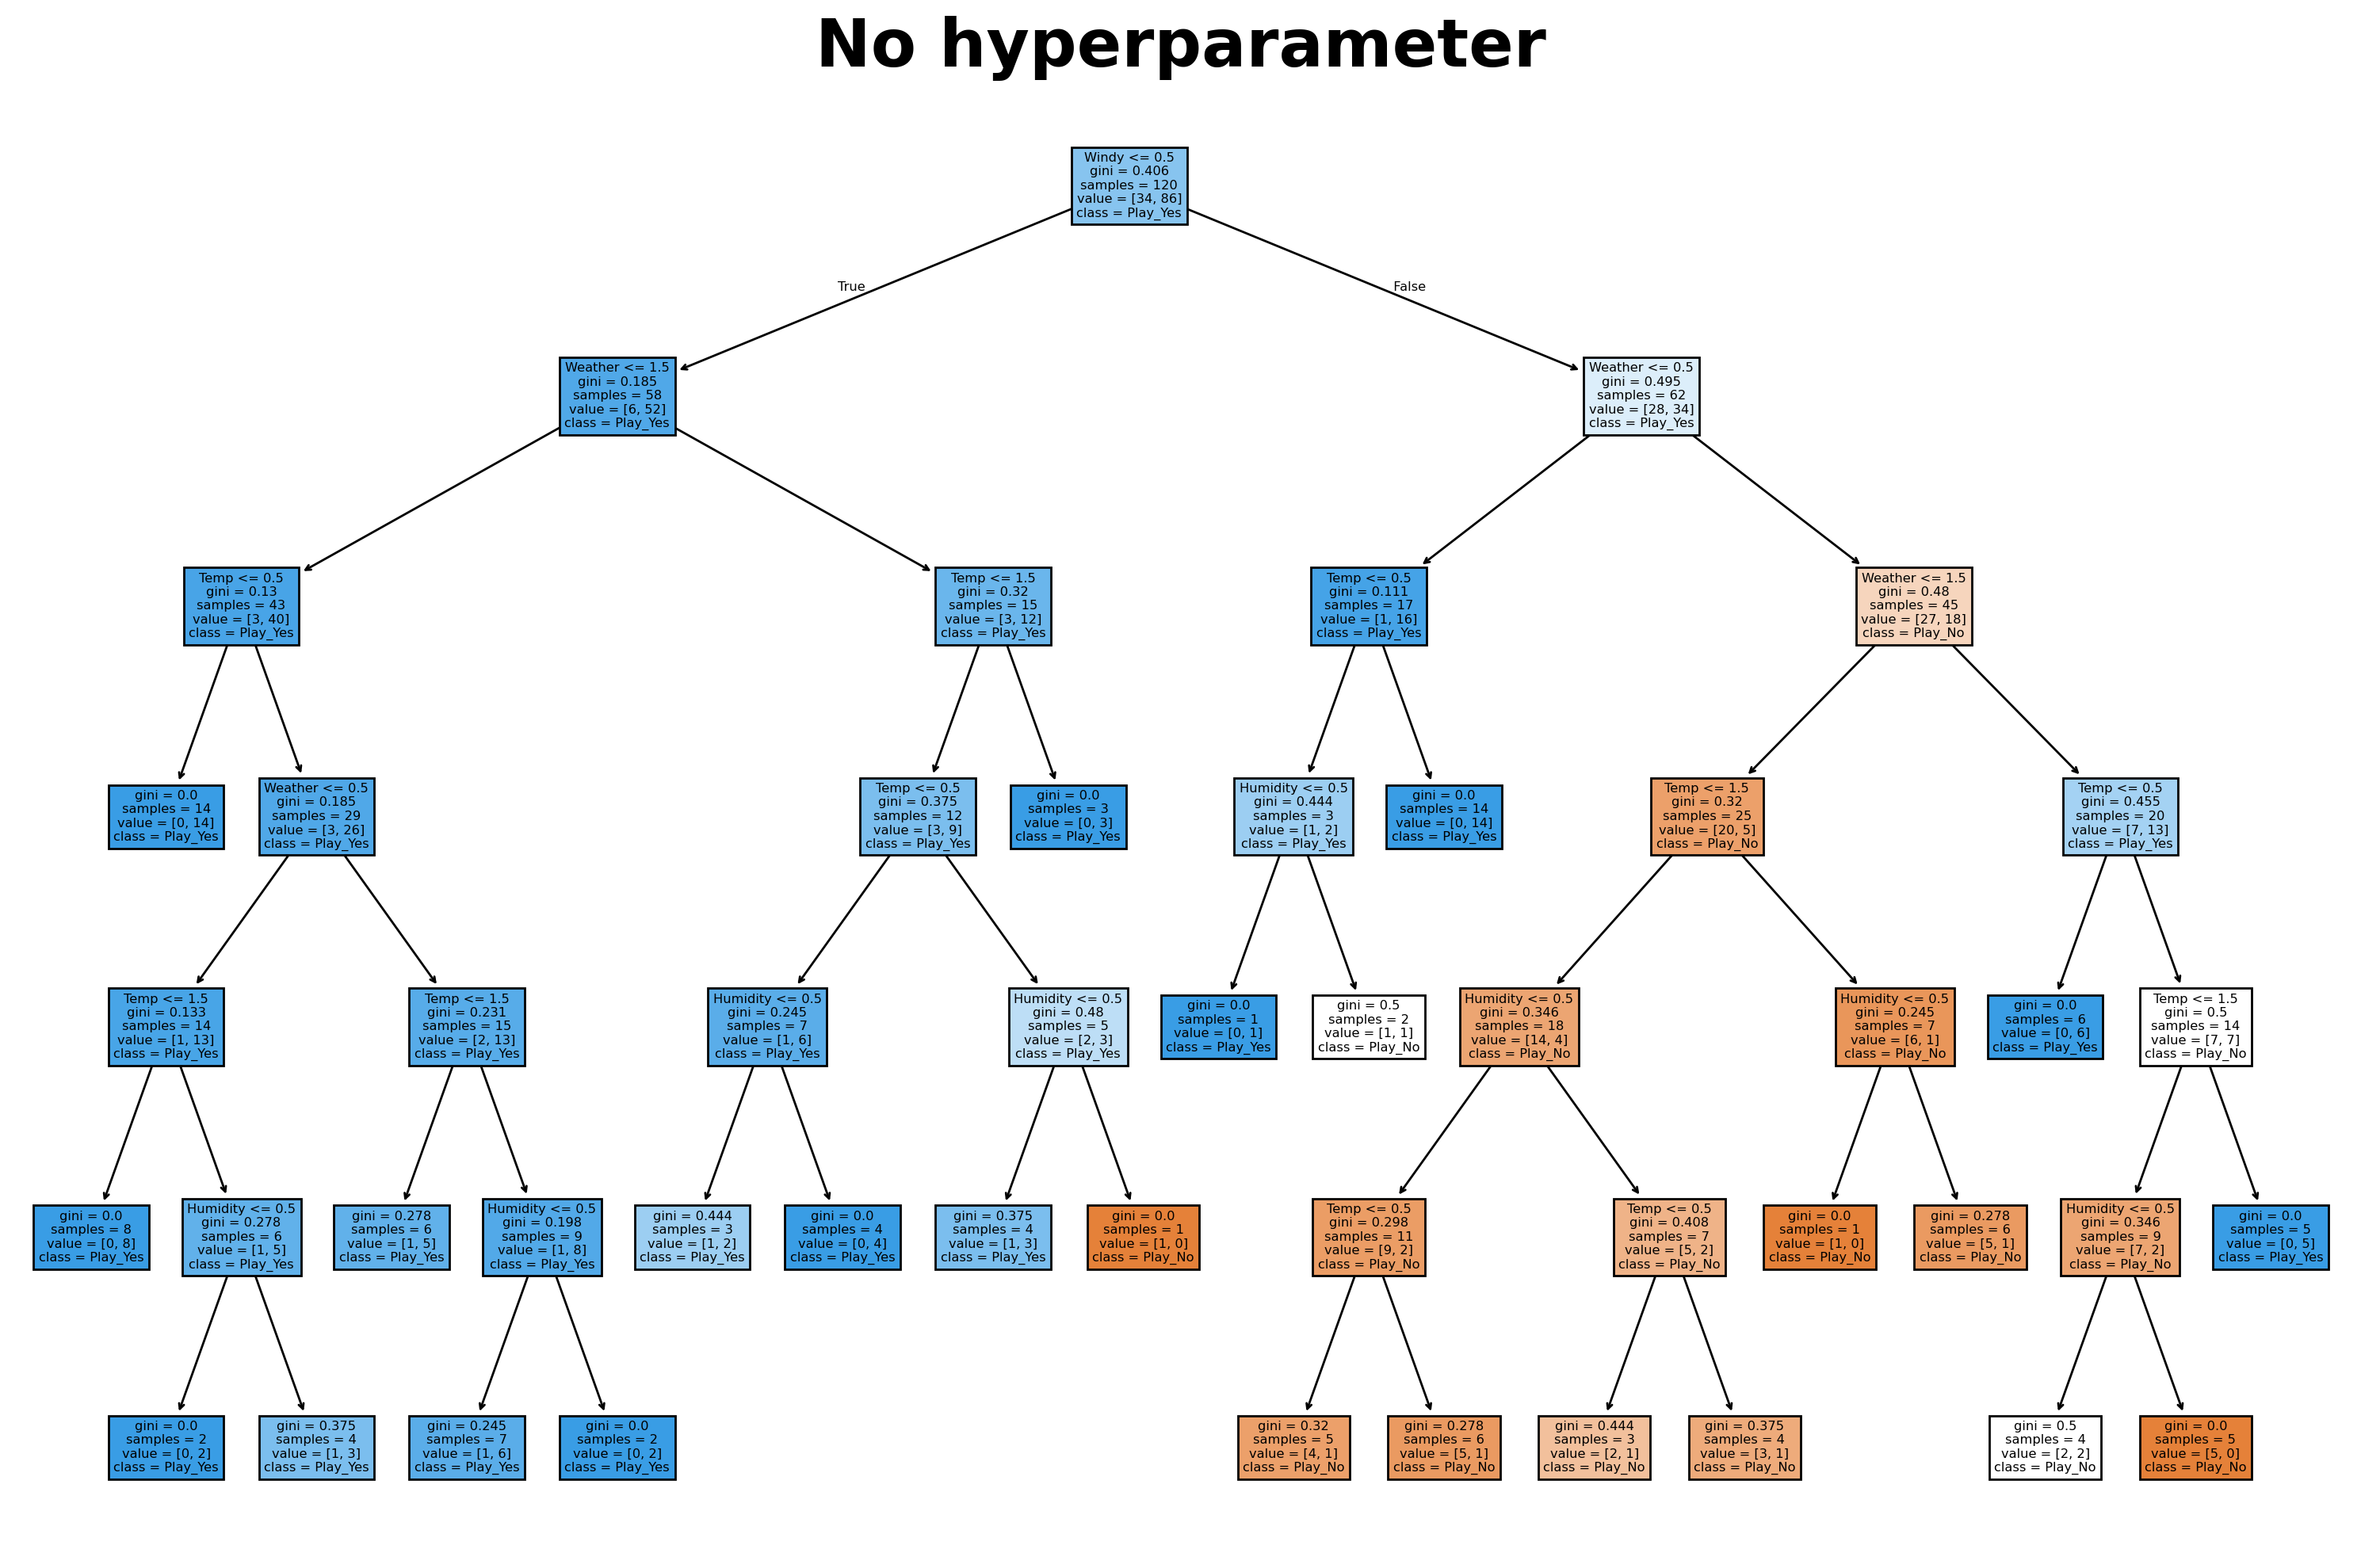

In [ ]:
from sklearn import tree
plt.figure(figsize=(15,10), dpi=200)
tree.plot_tree(
    model,
    feature_names = X_train.columns,
    class_names = le_play.classes_,
    filled = True
)
plt.title('No hyperparameter', fontsize=30, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score
print("Accuracy  :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))

Accuracy  : 0.8
Precision : 0.7916666666666666
Recall    : 0.95
F1 Score  : 0.8636363636363636


# criterion = {“gini”, “entropy”, “log_loss”}, default = ”gini”

In [ ]:
# model = DecisionTreeClassifier(criterion='gini')

In [ ]:
f1_score_list = []

# max_depth = int / float, default=None




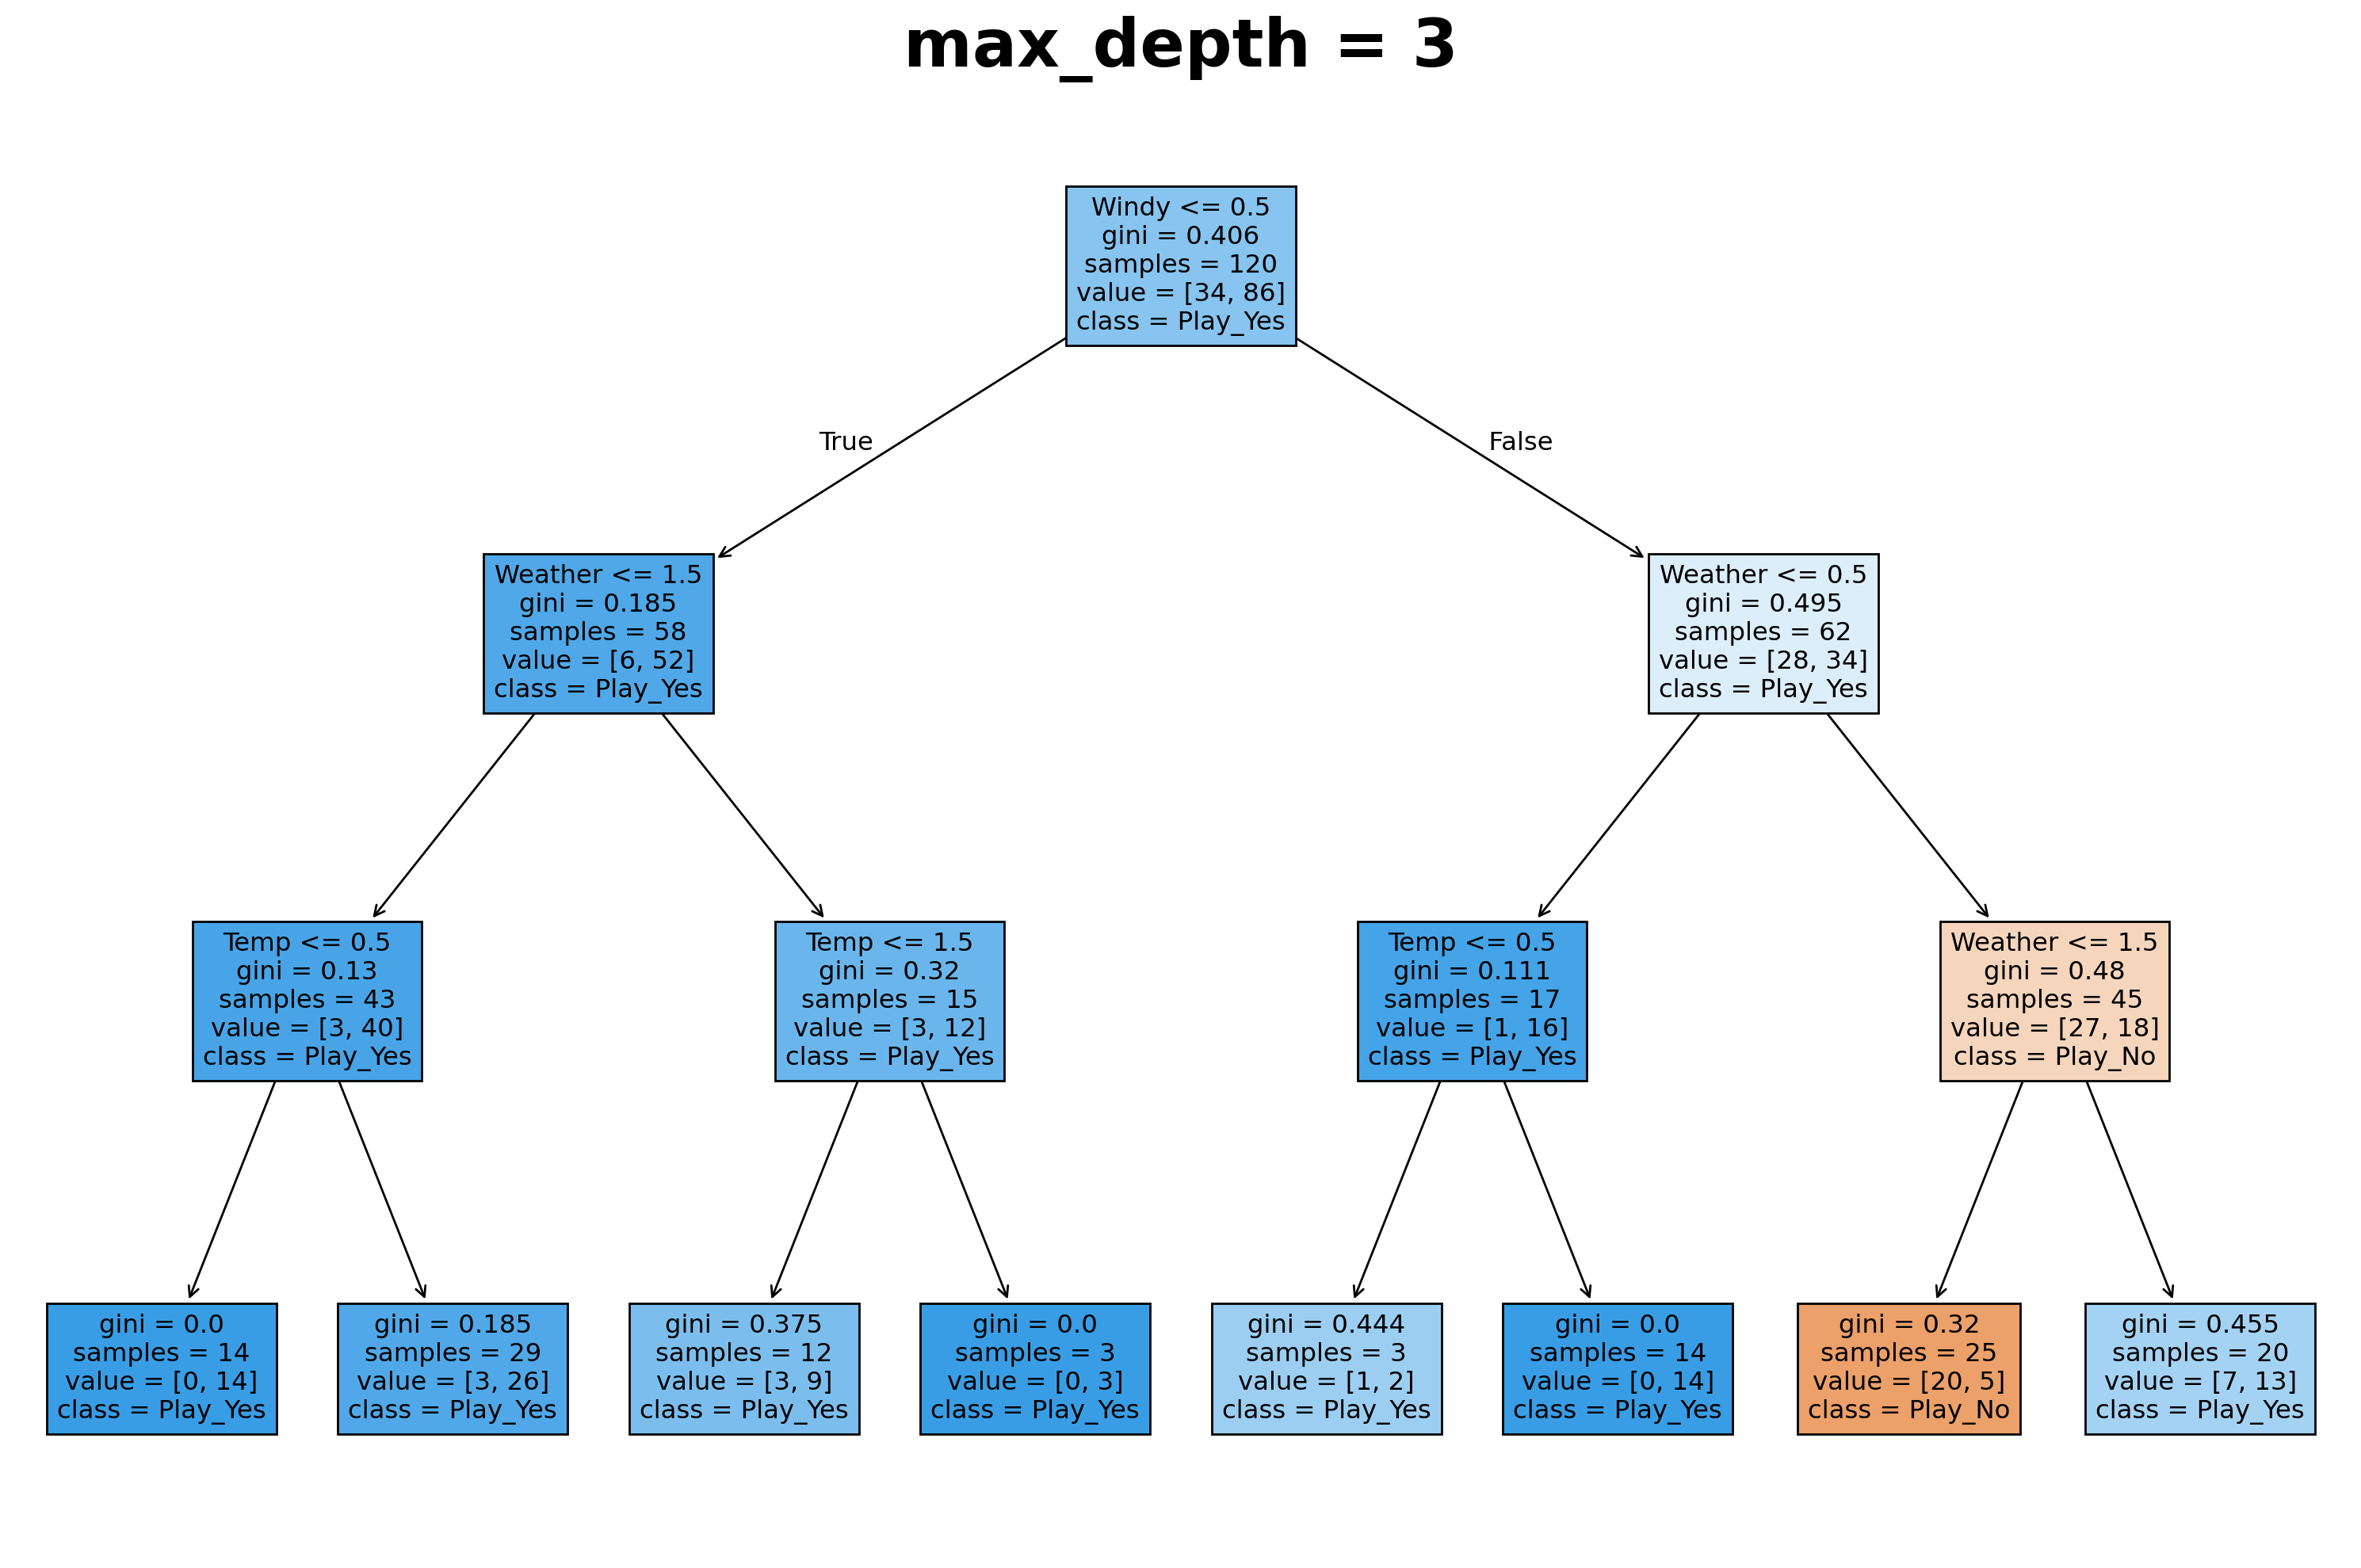

In [ ]:
model = DecisionTreeClassifier(max_depth=3) # Overfitting control
model.fit(X_train,y_train)
plt.figure(figsize=(15,10),dpi=200)
tree.plot_tree(
    model,
    feature_names = X_train.columns,
    class_names = le_play.classes_,
    filled = True
)
plt.title('max_depth = 3', fontsize=30, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
y_pred = model.predict(X_test)
f1_score_list.append(round(f1_score(y_test, y_pred),4))
f1_score_list

[0.8696]

# max_features = int / float or, {“sqrt”, “log2”}, default=None

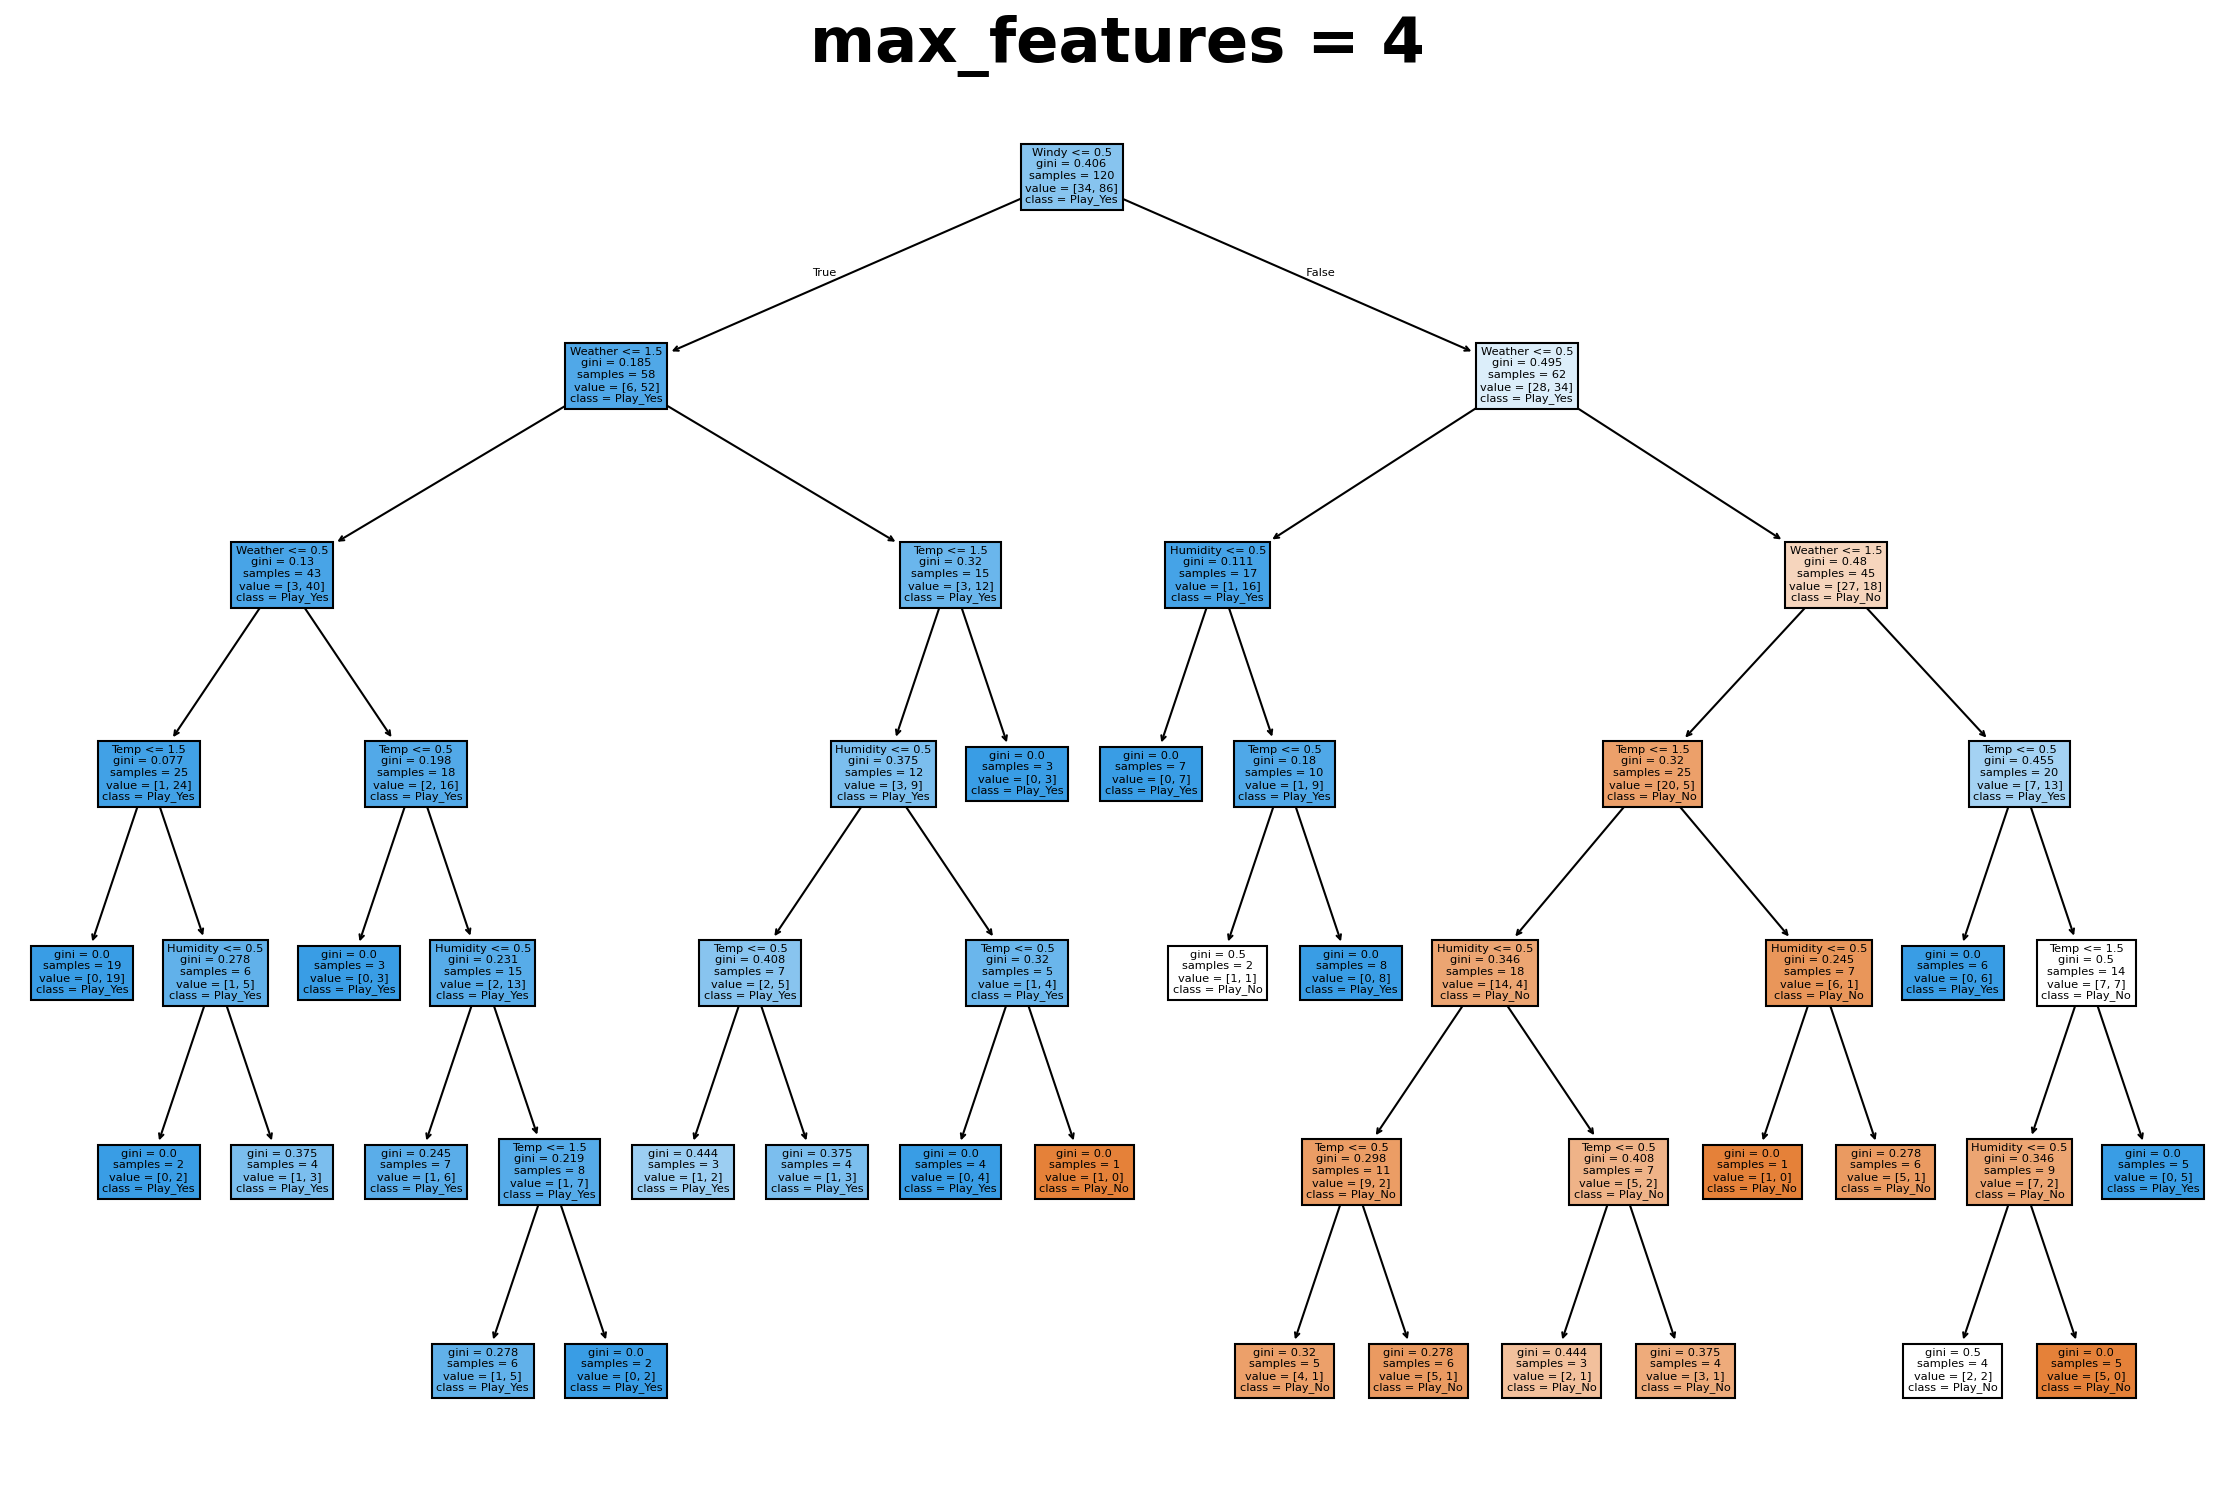

In [ ]:
model = DecisionTreeClassifier(max_features="log2")
model.fit(X_train,y_train)
plt.figure(figsize=(15,10), dpi=150)
tree.plot_tree(
    model,
    feature_names = X_train.columns,
    class_names = le_play.classes_,
    filled = True
)
plt.title('max_features = 4', fontsize=30, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
y_pred = model.predict(X_test)
f1_score_list.append(round(f1_score(y_test, y_pred),4))
f1_score_list

[0.8696, 0.8636]

# min_samples_split = int / float, default = 2

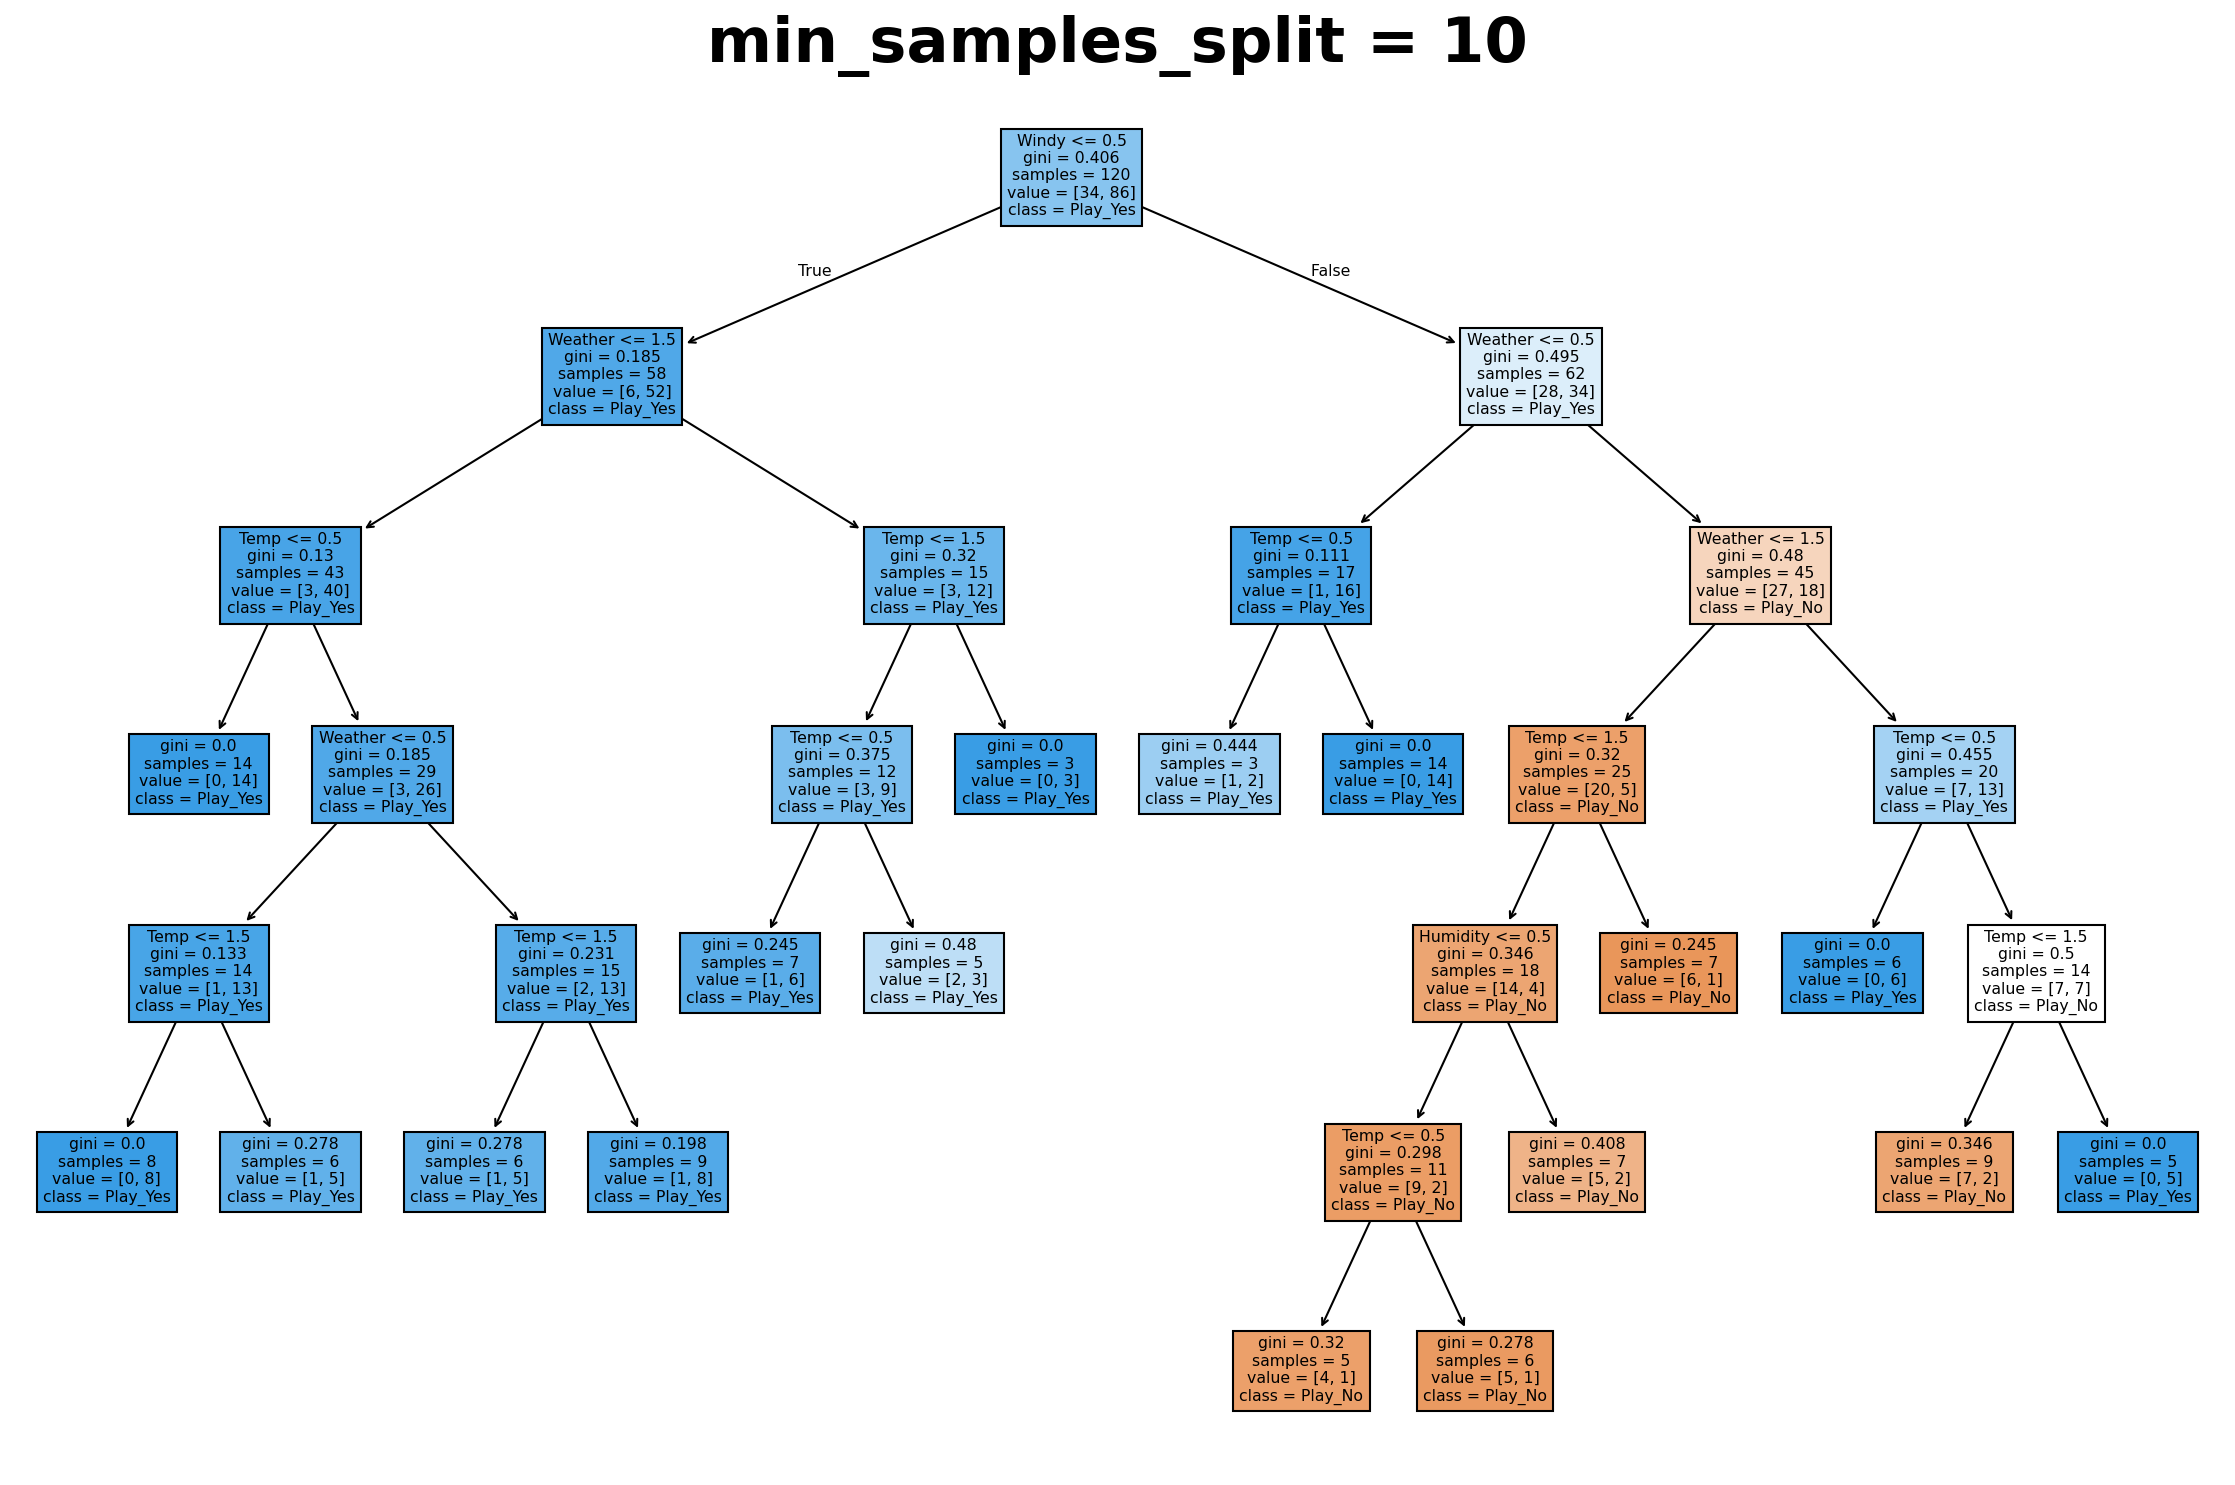

In [ ]:
model = DecisionTreeClassifier(min_samples_split=10)
model.fit(X_train,y_train)
plt.figure(figsize=(15,10), dpi=150)
tree.plot_tree(
    model,
    feature_names = X_train.columns,
    class_names = le_play.classes_,
    filled = True
)
plt.title('min_samples_split = 10', fontsize=30, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
y_pred = model.predict(X_test)
f1_score_list.append(round(f1_score(y_test, y_pred),4))
f1_score_list

[0.8696, 0.8636, 0.8889]

# min_samples_leaf = int / float, default = 1

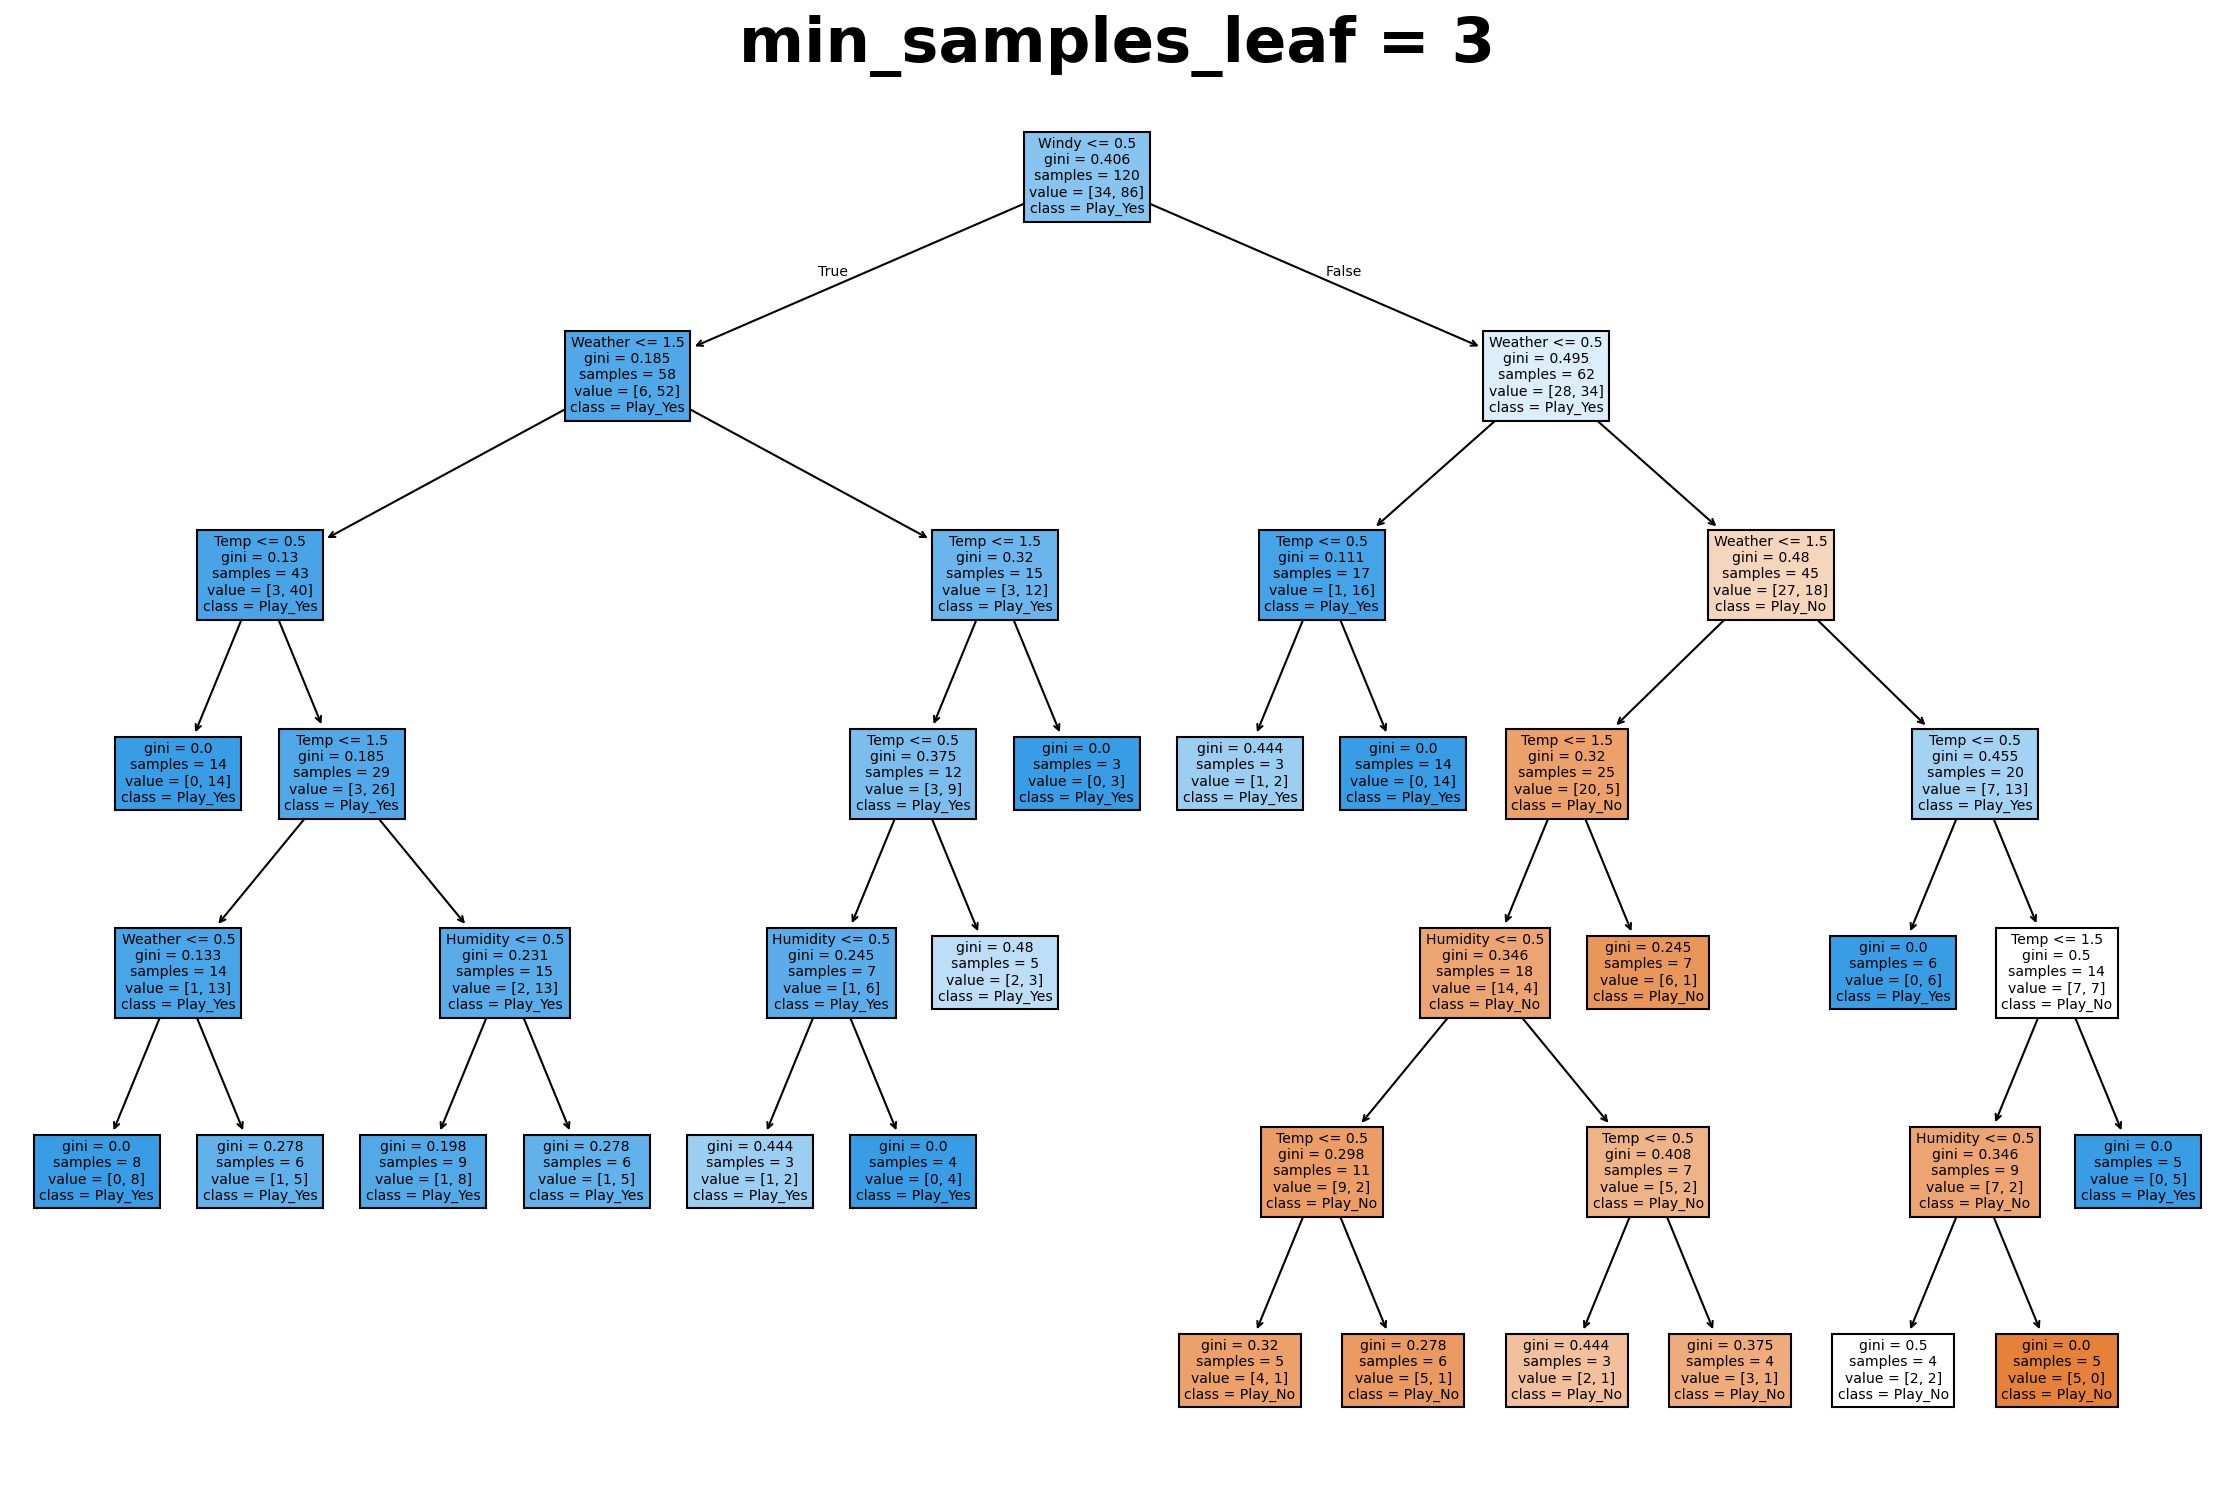

In [ ]:
model = DecisionTreeClassifier(min_samples_leaf=3)
model.fit(X_train,y_train)
plt.figure(figsize=(15,10), dpi=150)
tree.plot_tree(
    model,
    feature_names = X_train.columns,
    class_names = le_play.classes_,
    filled = True
)
plt.title('min_samples_leaf = 3', fontsize=30, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
y_pred = model.predict(X_test)
f1_score_list.append(round(f1_score(y_test, y_pred),4))
f1_score_list

[0.8696, 0.8636, 0.8889, 0.8889]

# max_leaf_nodes = int , default = None

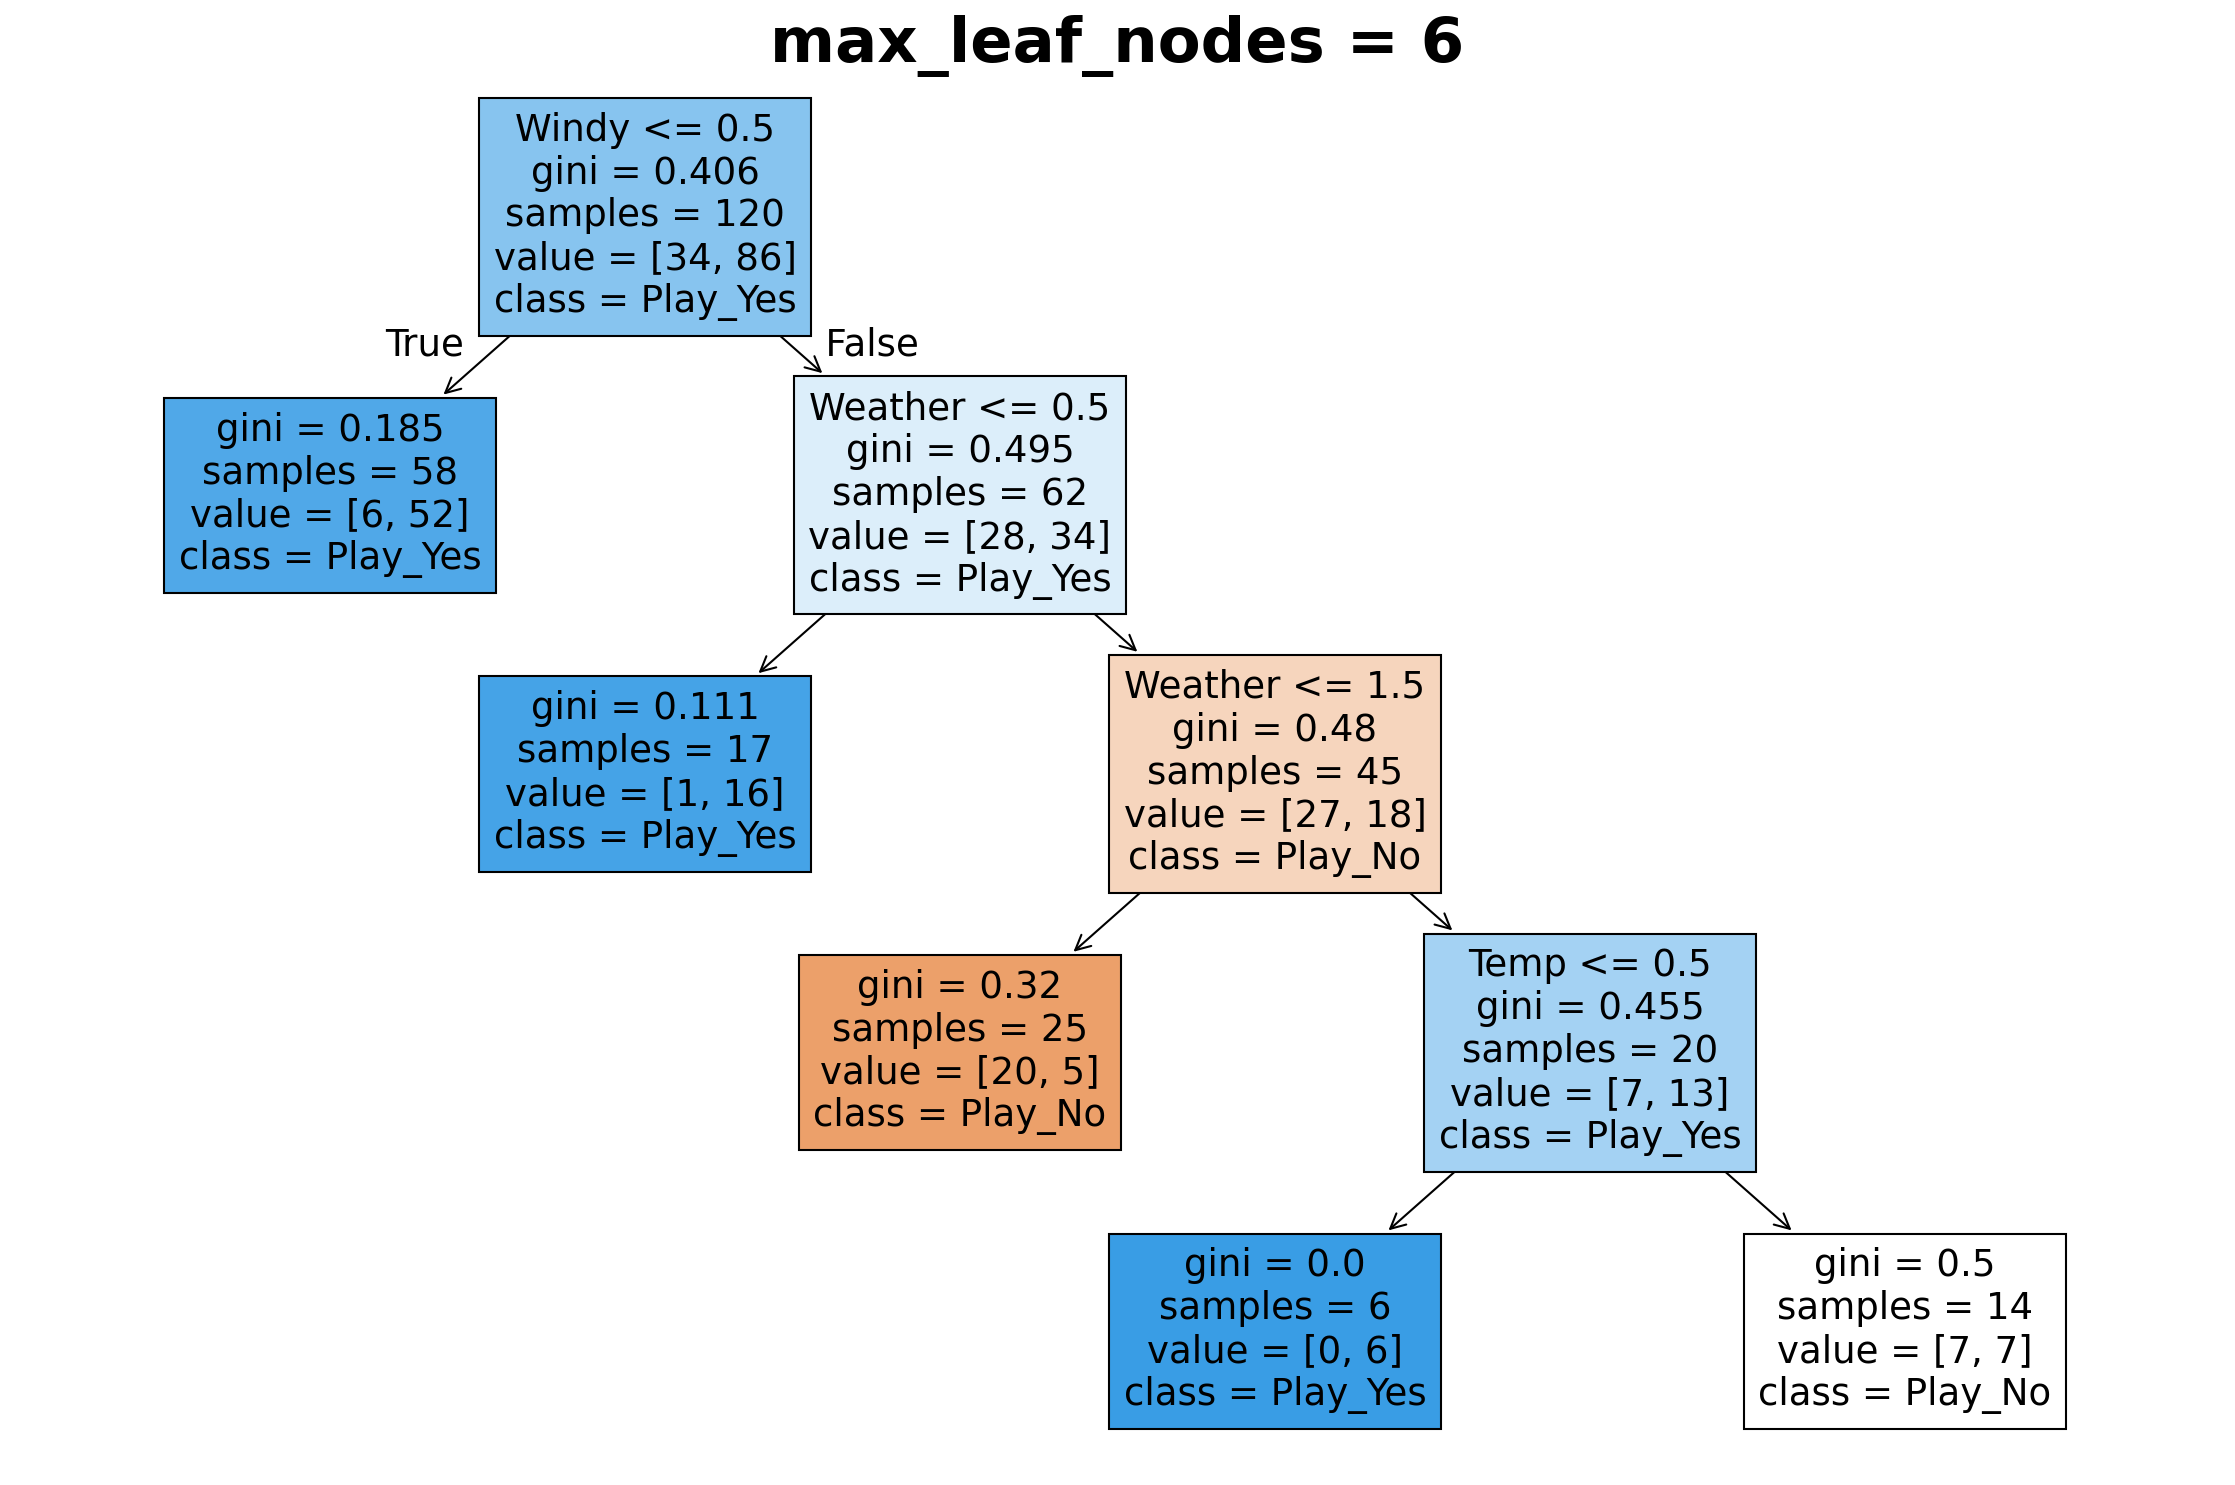

In [ ]:
model = DecisionTreeClassifier(max_leaf_nodes=5)
model.fit(X_train,y_train)
plt.figure(figsize=(15,10), dpi=150)
tree.plot_tree(
    model,
    feature_names = X_train.columns,
    class_names = le_play.classes_,
    filled = True
)
plt.title('max_leaf_nodes = 6', fontsize=30, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
y_pred = model.predict(X_test)
f1_score_list.append(round(f1_score(y_test, y_pred),4))
f1_score_list

[0.8696, 0.8636, 0.8889, 0.8889, 0.8837]

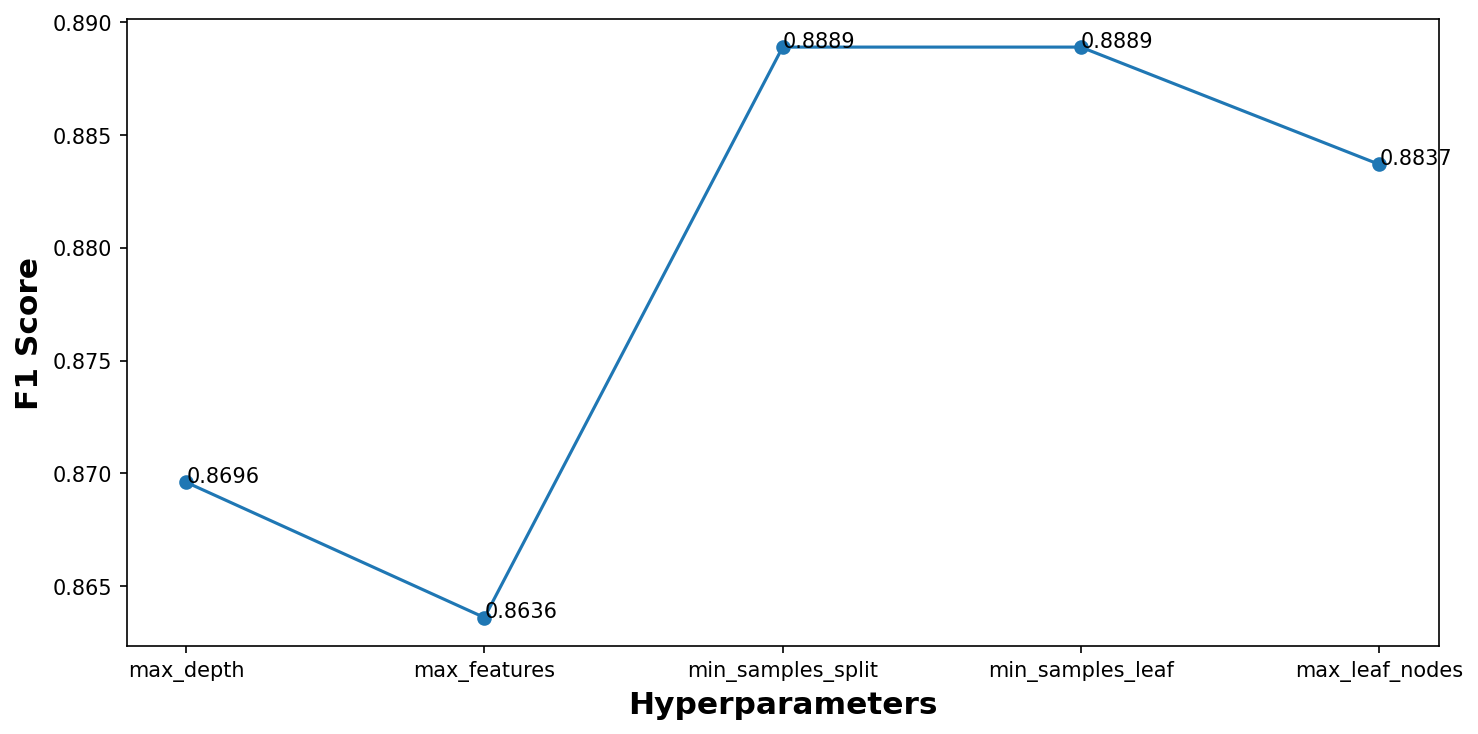

In [ ]:
a = ['max_depth', 'max_features', 'min_samples_split', 'min_samples_leaf', 'max_leaf_nodes']
plt.figure(figsize=(10,5), dpi=150)
plt.plot(a, f1_score_list, marker='o')
for i in range(len(a)):
    plt.annotate(f1_score_list[i], (a[i], f1_score_list[i]))
plt.xlabel('Hyperparameters', fontsize=15, fontweight='bold')
plt.ylabel('F1 Score', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()